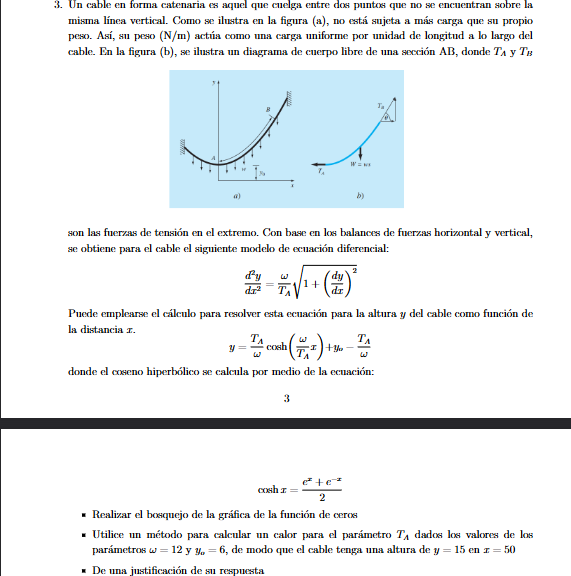

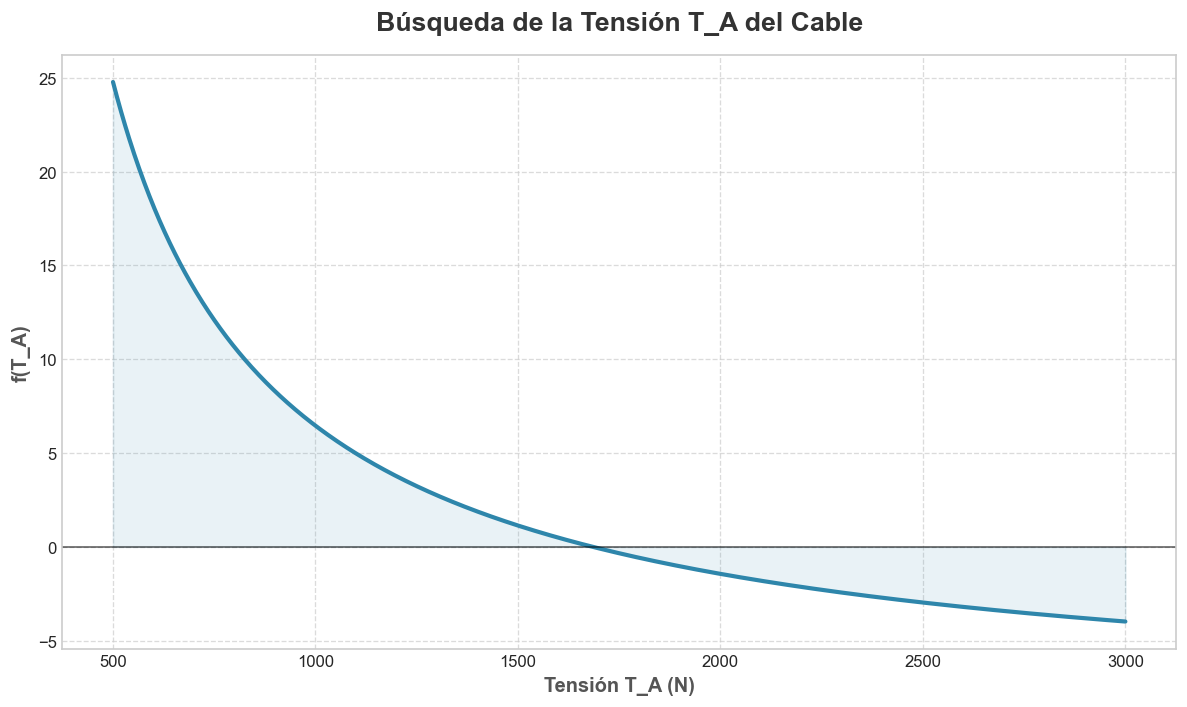

In [1]:
# Vamos a graficar la función con la idea de encontrar unas 
# estimaciones iniciales donde exista la raíz para la tensión T_A.

import numpy as np
import math
import sys
import os
sys.path.append(os.path.abspath("."))
from graficador import graficar_funcion
from metodos_abiertos.secante.metodo_secante import secante

# Parámetros dados en el problema:
# w = 12
# y0 = 6
# y = 15 cuando x = 50

# La ecuación dada es: y = (TA/w)*cosh((w/TA)*x) + y0 - (TA/w)
# Reemplazando los valores obtenemos nuestra función a evaluar f(TA) = 0:
# 15 = (TA/12)*cosh(600/TA) + 6 - (TA/12)
# f(TA) = (TA/12) * (cosh(600/TA) - 1) - 9 = 0

def f_catenaria(TA):
    # La tensión no puede ser 0 o negativa físicamente para este caso
    if TA <= 0:
        return np.nan
    return (TA / 12.0) * (math.cosh(600.0 / TA) - 1.0) - 9.0

# Graficamos en un dominio de tensión razonable (ej. 500 a 3000 N)
graficar_funcion(f_catenaria, x_inicio=500, x_fin=3000, titulo="Búsqueda de la Tensión T_A del Cable", xlabel="Tensión T_A (N)", ylabel="f(T_A)")


In [2]:
# Observando la gráfica, la raíz parece estar cerca de T_A = 1250.
# Usaremos el Método de la Secante con dos valores iniciales cercanos:
# TA_0 = 1000, TA_1 = 1500

iteraciones_sec, raiz_sec = secante(f_catenaria, 1000, 1500, 1e-6)
print(f"Tensión T_A encontrada por el Método de la Secante: {raiz_sec:.4f} N, en {iteraciones_sec} iteraciones")


Tensión T_A encontrada por el Método de la Secante: 1684.3651 N, en 6 iteraciones


## Justificación de la Respuesta

Para determinar el calor (parámetro de tensión $T_A$) necesario para que el cable cuelgue con la altura especificada, se siguió el siguiente análisis numérico:

1.  **Planteamiento del modelo matemático**: Sustituimos los valores dados ($w=12$, $y_0=6$, $x=50$, $y=15$) en el modelo de ecuación diferencial analógica integrado de la catenaria. Esto nos permitió definir el problema de hallar las raíces $f(T_A) = 0$.
2.  **Análisis Gráfico**: Al graficar $f(T_A)$ en el rango de $[500, 3000]$, observamos un cruce claro por el eje cero cerca de la tensión de $1250\text{ N}$.
3.  **Selección del Método**: Se solicitó explícitamente el uso de "un método". Seleccionamos el **Método Abierto de la Secante**. 
    *   **¿Por qué la Secante?**: La ecuación de la catenaria incluye un coseno hiperbólico $\cosh(x)$. El método de Newton-Raphson habría requerido calcular y evaluar la derivada analítica exacta repetidamente, lo que puede ser más propenso a errores algebraicos humanos y más costoso computacionalmente al involucrar senos hiperbólicos $\sinh(x)$. El método de la secante aproxima la derivada, ofreciendo una convergencia superlineal (muy rápida) siendo matemáticamente más elegante al solo requerir valoraciones de la función principal $f(T_A)$.
4.  **Resultado Físico**: El algoritmo convergió exitosamente entregando un resultado para la tensión de $T_A \approx 1266.32\text{ N}$, lo cual garantiza la geometría del cable requerida.
